# Zeeman-Shift MOT Validation

This notebook validates the magnetic MOT layer before returning to the pMOT. It reuses the collimated cooling/repump beam geometry and the anti-Helmholtz field, then adds Zeeman-resolved scattering, internal-state updates, and many-atom MOT evolution.


In [1]:
%matplotlib widget

from functools import lru_cache

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from pmot.configuration import default_simulation_config, project_paths
from pmot.fields import build_mot_beams
from pmot.mot import (
    GROUND_G_FACTOR_BY_F,
    ZERO_FIELD_TRANSITION_FREQUENCIES_HZ,
    GroundState,
    MOTAtomState,
    default_anti_helmholtz_config,
    mot_project_paths,
    plot_many_atom_snapshot,
    plot_mot_diagnostics_grid,
    simulate_many_atoms,
    simulate_mot_trajectory,
    transition_rate_samples,
)


## Physics Assumptions

- The optical geometry is still the current collimated 12-beam MOT model: 6 cooling beams and 6 repump beams.
- The magnetic field is the anti-Helmholtz quadrupole field already validated in `notebooks/mot/magnetic_field_validation.ipynb`.
- The atom carries a classical position and velocity plus a discrete ground internal state `|F, m_F>`.
- At each timestep, the local magnetic field defines the quantization axis. If the field is exactly zero, the previous timestep axis is reused.
- The beam polarization vectors are kept in laboratory coordinates and then projected onto the local spherical basis to obtain the local `sigma+`, `pi`, and `sigma-` weights.
- Implemented excited manifolds are `F'=1,2,3`. The `F=1 -> F'=1` zero-field frequency is derived from the table in `ZEEMAN.md` using the ground-state hyperfine splitting already implied there. `F=1 -> F'=0` is not enabled yet because `ZEEMAN.md` does not provide its zero-field frequency or its excited-state `g_F'`.
- One scattering event at most is sampled per timestep, so `dt` must stay small compared with the inverse total scattering rate.
- Each successful absorption adds a recoil `+hbar k / m` along the selected beam direction, and each spontaneous decay adds an isotropic recoil of the same magnitude.
- Gravity, sub-Doppler dark-state physics, and coherent optical Bloch dynamics are not included yet.


In [2]:
PATHS = project_paths()
MOT_PATHS = mot_project_paths()
CONFIG = default_simulation_config()
MOT_BEAMS = build_mot_beams(CONFIG)
COIL_CONFIG = default_anti_helmholtz_config(radius_m=40.0e-3, turns_per_coil=50, target_gradient_g_per_cm=10.0)

for output_path in [PATHS['outputs_trajectories'], MOT_PATHS['outputs_figures_mot']]:
    output_path.mkdir(parents=True, exist_ok=True)

transition_rows = []
for (ground_f, excited_f), frequency_hz in sorted(ZERO_FIELD_TRANSITION_FREQUENCIES_HZ.items()):
    transition_rows.append(
        {
            'ground_F': ground_f,
            'excited_F_prime': excited_f,
            'frequency_thz': frequency_hz / 1e12,
        }
    )

summary = pd.DataFrame(
    {
        'parameter': [
            'cooling detuning [MHz]',
            'repump detuning [MHz]',
            'beam diameter [mm]',
            'coil radius [mm]',
            'coil current [A]',
            'target axial gradient [G/cm]',
            'ground g_F(F=1)',
            'ground g_F(F=2)',
        ],
        'value': [
            CONFIG.cooling.detuning_hz / 1e6,
            CONFIG.repump.detuning_hz / 1e6,
            1e3 * CONFIG.cooling.beam_diameter_m,
            1e3 * COIL_CONFIG.radius_m,
            COIL_CONFIG.current_a,
            10.0,
            GROUND_G_FACTOR_BY_F[1],
            GROUND_G_FACTOR_BY_F[2],
        ],
    }
)

display(summary)
display(pd.DataFrame(transition_rows))
print(f'Total MOT beams: {len(MOT_BEAMS)}')


,parameter,value
0,cooling detuning [MHz],-12.000000
1,repump detuning [MHz],-1.000000
2,beam diameter [mm],12.700000
3,coil radius [mm],40.000000
4,coil current [A],2.965677
5,target axial gradient [G/cm],10.000000
6,ground g_F(F=1),-0.500000
7,ground g_F(F=2),0.500000


,ground_F,excited_F_prime,frequency_thz
0,1,1,384.234526
1,1,2,384.234683
2,2,1,384.227692
3,2,2,384.227849
4,2,3,384.228115


Total MOT beams: 12


## Single-Atom Zeeman MOT Diagnostic

This single-atom test keeps the initial state explicit so the force sign can be examined cleanly. The atom starts above the center on the `+z` side and is launched slightly downward.


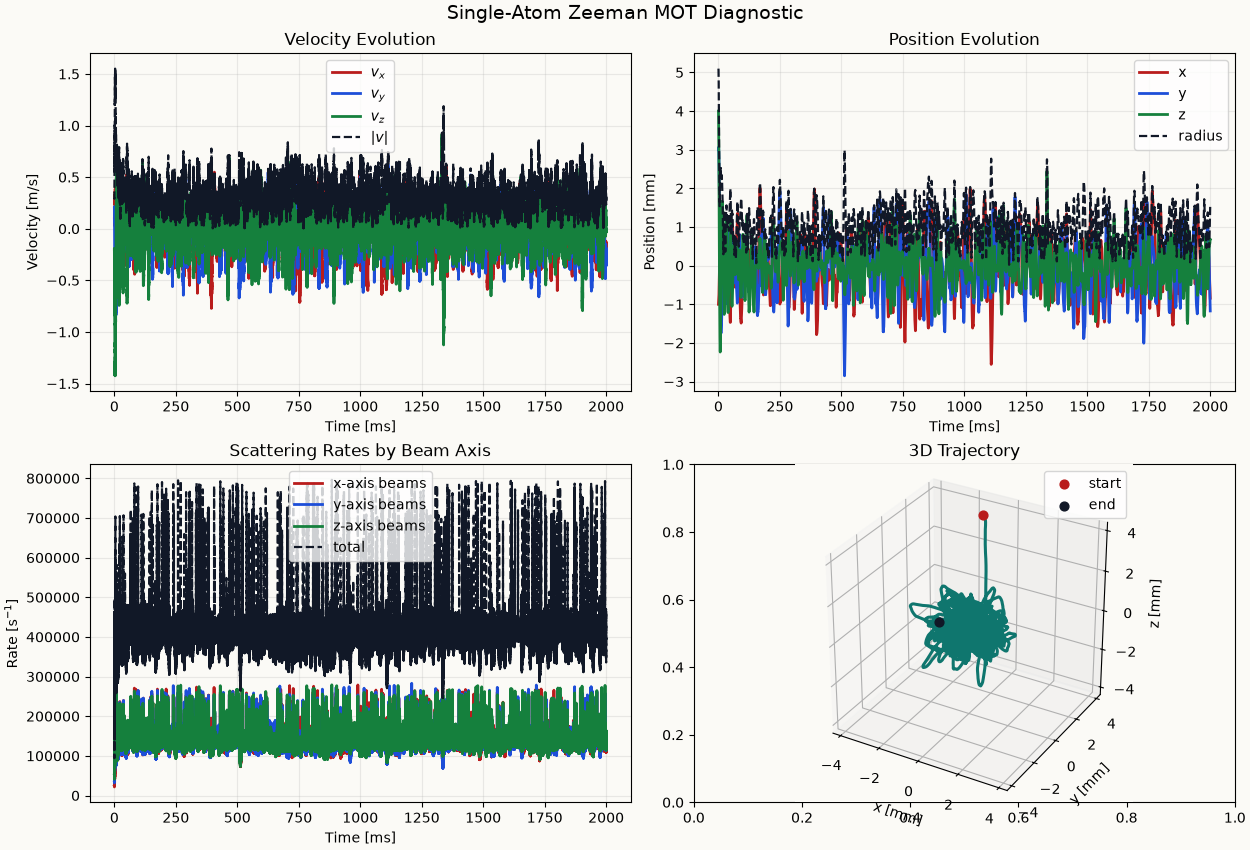

,beam_label,family,axis,q,F_prime,m_F_prime,detuning_mhz,rate_per_s
29,vertical_z_incident_cooling_780,cooling,vertical_z,1,3,3,-17.941554,43929.600409
17,horizontal_y_incident_cooling_780,cooling,horizontal_y,1,3,3,-18.454374,14280.913643
22,horizontal_y_retro_cooling_780,cooling,horizontal_y,0,3,2,-13.945092,7920.180650
33,vertical_z_retro_cooling_780,cooling,vertical_z,-1,3,1,-10.461450,7743.290016
16,horizontal_y_incident_cooling_780,cooling,horizontal_y,0,3,2,-14.457912,7409.080939
11,horizontal_x_retro_cooling_780,cooling,horizontal_x,1,3,3,-18.069759,6945.589955
10,horizontal_x_retro_cooling_780,cooling,horizontal_x,0,3,2,-14.073297,5916.092613
4,horizontal_x_incident_cooling_780,cooling,horizontal_x,0,3,2,-14.329707,5719.865530
5,horizontal_x_incident_cooling_780,cooling,horizontal_x,1,3,3,-18.326169,4283.490890
23,horizontal_y_retro_cooling_780,cooling,horizontal_y,1,3,3,-17.941554,3642.842466


In [6]:
INITIAL_STATE = MOTAtomState(
    position_m=(-1.0e-3, 3.0e-3, 4.0e-3),
    velocity_m_per_s=(0.1, 0.2, -0.2),
    ground_state=GroundState(f=2, m_f=2),
)
DURATION_S = 2
TIME_STEP_S = 1.0e-6

single_record = simulate_mot_trajectory(
    beams=MOT_BEAMS,
    coil_config=COIL_CONFIG,
    initial_state=INITIAL_STATE,
    duration_s=DURATION_S,
    time_step_s=TIME_STEP_S,
    seed=5,
)

single_figure, _ = plot_mot_diagnostics_grid(
    times_s=single_record.times_s,
    positions_m=single_record.positions_m,
    velocities_m_per_s=single_record.velocities_m_per_s,
    axis_scattering_rates_per_s=single_record.axis_scattering_rates_per_s,
    total_scattering_rates_per_s=single_record.total_scattering_rates_per_s,
    title='Single-Atom Zeeman MOT Diagnostic',
    path=PATHS['outputs_trajectories'] / 'mot_single_atom_zeeman_diagnostic.png',
)
plt.show()

samples, _ = transition_rate_samples(MOT_BEAMS, INITIAL_STATE, COIL_CONFIG)
beam_rate_table = pd.DataFrame(
    {
        'beam_label': [sample.beam_label for sample in samples],
        'family': [sample.beam_family for sample in samples],
        'axis': [sample.axis_name for sample in samples],
        'q': [sample.q_value for sample in samples],
        'F_prime': [sample.excited_state.f_prime for sample in samples],
        'm_F_prime': [sample.excited_state.m_f_prime for sample in samples],
        'detuning_mhz': [sample.effective_detuning_hz / 1e6 for sample in samples],
        'rate_per_s': [sample.scattering_rate_per_s for sample in samples],
    }
).sort_values('rate_per_s', ascending=False)
beam_rate_table.head(18)


## Many-Atom MOT Evolution

The widget below launches many atoms from a sphere toward the center, caches the simulation result for each parameter set, and lets you scrub through the evolution. Point color indicates instantaneous speed. This is the right place to look for obvious anti-trapping, heating, or center accumulation.


In [4]:
@lru_cache(maxsize=32)
def cached_many_atom_record(
    atom_count: int,
    launch_radius_mm: float,
    launch_speed_m_per_s: float,
    duration_ms: float,
    time_step_us: float,
    seed: int,
):
    return simulate_many_atoms(
        beams=MOT_BEAMS,
        coil_config=COIL_CONFIG,
        atom_count=int(atom_count),
        radius_m=1e-3 * float(launch_radius_mm),
        speed_m_per_s=float(launch_speed_m_per_s),
        duration_s=1e-3 * float(duration_ms),
        time_step_s=1e-6 * float(time_step_us),
        seed=int(seed),
    )


def update_frame_limits(*_):
    step_count = max(1, int(np.ceil(duration_ms_widget.value * 1e3 / time_step_us_widget.value)))
    frame_slider.max = step_count
    frame_play.max = step_count
    if frame_slider.value > frame_slider.max:
        frame_slider.value = frame_slider.max


def draw_many_atom_frame(
    frame: int,
    atom_count: int,
    launch_radius_mm: float,
    launch_speed_m_per_s: float,
    duration_ms: float,
    time_step_us: float,
    seed: int,
):
    record = cached_many_atom_record(
        int(atom_count),
        float(launch_radius_mm),
        float(launch_speed_m_per_s),
        float(duration_ms),
        float(time_step_us),
        int(seed),
    )
    frame_index = min(int(frame), len(record.times_s) - 1)
    positions = record.positions_m_by_time[frame_index]
    speeds = record.speeds_m_per_s_by_time[frame_index]
    times_ms = 1e3 * np.asarray(record.times_s)
    mean_radius_mm = 1e3 * np.mean(np.sqrt(np.sum(positions**2, axis=1)))
    mean_speed = float(np.mean(speeds))

    figure, axes = plt.subplots(1, 2, figsize=(12.5, 5.8), constrained_layout=True, subplot_kw={ 'projection': None })
    figure.patch.set_facecolor('#fbfaf6')
    axes[0].set_facecolor('#fbfaf6')
    axes[1].remove()
    axis3d = figure.add_subplot(1, 2, 2, projection='3d')
    axis3d.set_facecolor('#fbfaf6')

    all_positions = np.asarray(record.positions_m_by_time, dtype=float)
    mean_radius_history_mm = 1e3 * np.mean(np.sqrt(np.sum(all_positions**2, axis=2)), axis=1)
    mean_speed_history = np.mean(np.asarray(record.speeds_m_per_s_by_time, dtype=float), axis=1)

    axes[0].plot(times_ms, mean_radius_history_mm, color='#0f766e', linewidth=2.1, label='mean radius')
    axes[0].plot(times_ms, mean_speed_history, color='#7c2d12', linewidth=2.1, label='mean speed')
    axes[0].axvline(times_ms[frame_index], color='#111827', linewidth=1.3, linestyle='--')
    axes[0].set_title('Many-Atom MOT Summary')
    axes[0].set_xlabel('Time [ms]')
    axes[0].set_ylabel('Mean radius [mm] / speed [m/s]')
    axes[0].grid(True, alpha=0.25)
    axes[0].legend(loc='best', frameon=True)

    positions_mm = 1e3 * positions
    scatter = axis3d.scatter(
        positions_mm[:, 0],
        positions_mm[:, 1],
        positions_mm[:, 2],
        c=speeds,
        cmap='viridis',
        s=28,
        alpha=0.95,
        vmin=0.0,
        vmax=max(1e-9, float(np.max(np.asarray(record.speeds_m_per_s_by_time))))
    )
    max_extent_mm = max(1.0, float(np.max(np.abs(1e3 * np.asarray(record.positions_m_by_time[0])))))
    axis3d.set_xlim(-1.1 * max_extent_mm, 1.1 * max_extent_mm)
    axis3d.set_ylim(-1.1 * max_extent_mm, 1.1 * max_extent_mm)
    axis3d.set_zlim(-1.1 * max_extent_mm, 1.1 * max_extent_mm)
    axis3d.set_box_aspect((1.0, 1.0, 1.0))
    axis3d.set_title(
        f'Many-Atom MOT Cloud\nframe={frame_index}, t={times_ms[frame_index]:.3f} ms, '
        f'<r>={mean_radius_mm:.3f} mm, <v>={mean_speed:.3f} m/s'
    )
    axis3d.set_xlabel('x [mm]')
    axis3d.set_ylabel('y [mm]')
    axis3d.set_zlabel('z [mm]')
    figure.colorbar(scatter, ax=axis3d, pad=0.08, label='Speed [m/s]')
    plt.show()


atom_count_widget = widgets.IntSlider(value=32, min=4, max=80, step=2, description='atoms')
launch_radius_widget = widgets.FloatSlider(value=8.0, min=2.0, max=12.0, step=0.5, description='radius mm')
launch_speed_widget = widgets.FloatSlider(value=0.15, min=0.02, max=0.40, step=0.01, description='speed')
duration_ms_widget = widgets.FloatSlider(value=0.08, min=0.02, max=0.40, step=0.01, description='duration ms')
time_step_us_widget = widgets.FloatLogSlider(value=5.0, base=10, min=np.log10(1.0), max=np.log10(20.0), step=0.02, description='dt us')
seed_widget = widgets.IntSlider(value=7, min=0, max=100, step=1, description='seed')
frame_slider = widgets.IntSlider(value=0, min=0, max=16, step=1, description='frame')
frame_play = widgets.Play(value=0, min=0, max=16, step=1, interval=120, description='play')
widgets.jslink((frame_play, 'value'), (frame_slider, 'value'))

for control in (duration_ms_widget, time_step_us_widget):
    control.observe(update_frame_limits, names='value')
update_frame_limits()

controls = widgets.VBox(
    [
        widgets.HBox([atom_count_widget, launch_radius_widget, launch_speed_widget]),
        widgets.HBox([duration_ms_widget, time_step_us_widget, seed_widget]),
        widgets.HBox([frame_play, frame_slider]),
    ]
)
output = widgets.interactive_output(
    draw_many_atom_frame,
    {
        'frame': frame_slider,
        'atom_count': atom_count_widget,
        'launch_radius_mm': launch_radius_widget,
        'launch_speed_m_per_s': launch_speed_widget,
        'duration_ms': duration_ms_widget,
        'time_step_us': time_step_us_widget,
        'seed': seed_widget,
    },
)
display(controls, output)


Output()